# Train on mouse brain data

This could take several hours. The trained model is provided, which can be used to try the interpretation part without training again.

In [1]:
import os
import sys
sys.path.append("../")
device = "cuda"
import importlib


In [2]:
import scanpy as sc
import squidpy as sq
import pandas as pd
from tqdm.notebook import tqdm
import scipy as sp
import numpy as np
import multiprocessing
import pickle as pkl
import torch
import gc
import sklearn.metrics
import torch

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'arial'

pltkw = dict(bbox_inches='tight', transparent=True)

c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = parti

In [3]:
import steamboat as sf
import steamboat.tools
# importlib.reload(spaceformer.benchmarks)

In [4]:
task = 'select H'

if task == 'prepare data':
    adata = sc.read_h5ad("../data/Ex2_mouse_brain/Zhuang-ABCA-1-raw.h5ad")
    obs = pd.read_csv("../data/Ex2_mouse_brain/label.csv.gz", index_col=0)
    
    # obs = obs[obs['brain_section_label'].isin(obs['brain_section_label'].value_counts()[:10].index.tolist())]
    # adata = adata[obs.index, :]
    # adata.obs = obs
    # gc.collect()
    
    adata = adata[obs.index, :]
    gc.collect()
    adata.obs = obs
    gc.collect()
    
    adata.obsm['spatial'] = adata.obs[['x', 'y']].to_numpy()
    
    adata.write_h5ad("../data/Ex2_mouse_brain/Zhuang-ABCA-1-labeled.h5ad")

    selected_z = sorted(adata.obs['z'].unique())[:10:]
    selected_adata = adata[adata.obs['z'].isin(selected_z)]  
    selected_adata.write_h5ad("../data/Ex2_mouse_brain/Zhuang-ABCA-1-labeled-subset.h5ad")

elif task == 'select H':
    adata = sc.read_h5ad("../data/Ex2_mouse_brain/Zhuang-ABCA-1-labeled-subset.h5ad")
elif task == 'run':
    adata = sc.read_h5ad("G:/data/Ex2_mouse_brain/Zhuang-ABCA-1-labeled.h5ad")
    
adata

AnnData object with n_obs × n_vars = 92662 × 1122
    obs: 'brain_section_label', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'cluster_alias', 'x', 'y', 'z', 'subclass_confidence_score', 'cluster_confidence_score', 'high_quality_transfer', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'x_ccf', 'y_ccf', 'z_ccf', 'parcellation_index', 'parcellation_organ', 'parcellation_category', 'parcellation_division', 'parcellation_structure', 'parcellation_substructure', 'parcellation_organ_color', 'parcellation_category_color', 'parcellation_division_color', 'parcellation_structure_color', 'parcellation_substructure_color'
    var: 'gene_symbol'
    obsm: 'spatial'

In [5]:
if False:
    n_genes = 100
    np.random.seed(0)
    chosen_gene_mask = np.zeros(adata.shape[1])
    chosen_gene_mask[:n_genes] = 1.
    np.random.shuffle(chosen_gene_mask)
    chosen_gene_mask = chosen_gene_mask > 0.
    adata = adata[:, chosen_gene_mask]
gc.collect()

# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

In [6]:
adatas = []
for i in adata.obs['brain_section_label'].unique():
    adatas.append(adata[adata.obs['brain_section_label'] == i])
    adatas[-1].obs['global'] = 0

adatas = sf.prep_adatas(adatas, norm=False, log1p=False)
dataset = sf.make_dataset(adatas, sparse_graph=True, regional_obs=['global'])

C:\Users\lshh\AppData\Local\Temp\ipykernel_55888\3785553451.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adatas[-1].obs['global'] = 0
C:\Users\lshh\AppData\Local\Temp\ipykernel_55888\3785553451.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adatas[-1].obs['global'] = 0
C:\Users\lshh\AppData\Local\Temp\ipykernel_55888\3785553451.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adatas[-1].obs['global'] = 0
C:\Users\lshh\AppData\Local\Temp\ipykernel_55888\3785553451.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adatas[-1].obs['global'] = 0
C:\Users\lshh\AppData\Local\Temp\ipykernel_55888\3785553451.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adatas[-1].obs['global'] = 0
C:\Users\l

  0%|          | 0/10 [00:00<?, ?it/s]

Using ['global'] as regional annotations.


  0%|          | 0/10 [00:00<?, ?it/s]

In [7]:
# Hs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
max_entropy = sp.stats.entropy([1] * adata.shape[0])
Hs = [20, 30, 40, 50, 60, 70, 80, 90, 100]

center_kl = []
local_kl = []
global_kl = []

unif_distr = np.ones((adata.shape[0], 1))

for H in Hs:
    sf.set_random_seed(0)
    model = sf.Steamboat(adata.var_names.tolist(), n_heads=H, n_scales=3)
    model = model.to(device)

    if os.path.exists(f'saved_models/mmbrain_H{H}.pth'):
        model.load_state_dict(torch.load(f'saved_models/mmbrain_H{H}.pth', map_location=device))
    else:
        model.fit(dataset, entry_masking_rate=0.1, feature_masking_rate=0.1,
            max_epoch=10000, 
            loss_fun=torch.nn.MSELoss(reduction='sum'),
            opt=torch.optim.Adam, opt_args=dict(lr=0.1), stop_eps=1e-4, report_per=1000, stop_tol=200, device=device)
        torch.save(model.state_dict(), f'saved_models/mmbrain_H{H}.pth')

    sf.tools.calc_obs(adatas, dataset, model, get_recon=True)
    sf.tools.gather_obs(adata, adatas)
    
    center_kl.append(sp.stats.entropy(adata.obsm['q'], unif_distr, base=2, axis=0))
    local_kl.append(sp.stats.entropy(adata.obsm['local_k'], unif_distr, base=2, axis=0))
    global_kl.append(sp.stats.entropy(adata.obsm['global_k_0'], unif_distr, base=2, axis=0))

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [8]:
max_entropy = sp.stats.entropy([1] * adata.shape[0])
Hs = [20, 30, 40, 50, 60, 70, 80, 90, 100]

center_kl = []
local_kl = []
global_kl = []

unif_distr = np.ones((adata.shape[0], 1))
unif_distr_sample = np.ones((len(adatas), 1))

for H in Hs:
    sf.set_random_seed(0)
    model = sf.Steamboat(adata.var_names.tolist(), n_heads=H, n_scales=3)
    model = model.to(device)

    model.load_state_dict(torch.load(f'saved_models/mmbrain_H{H}.pth', map_location=device))
    
    sf.tools.calc_obs(adatas, dataset, model, get_recon=True)
    sf.tools.gather_obs(adata, adatas)
    # torch.save(model.state_dict(), f'saved_models/mmbrain_H{H}.pth')

    center_kl.append(sp.stats.entropy(adata.obsm['q'], unif_distr, base=2, axis=0))
    local_kl.append(sp.stats.entropy(adata.obsm['local_k'], unif_distr, base=2, axis=0))

    global_k = np.vstack([adatas[i].uns['global_k_0'] for i in range(len(adatas))])
    global_kl.append(sp.stats.entropy(global_k, unif_distr_sample, base=2, axis=0))

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

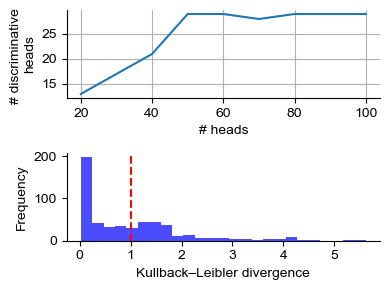

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(4, 3))

plt.sca(axes[0])
kl_pct = 50
kl_threshold = 1
(((local_kl_df > kl_threshold) + (global_kl_df > kl_threshold)).sum(axis=0)).plot()   
plt.xlabel('# heads')
plt.ylabel('# discriminative \nheads')
plt.grid()


plt.sca(axes[1])
plt.hist(local_kl_df.to_numpy().flatten(), bins=25, color='blue', alpha=0.7)
plt.axvline(1, color='red', ls='--')
plt.xlabel('Kullback–Leibler divergence')
plt.ylabel('Frequency')

plt.tight_layout()

for ax in axes:
    for pos in ['right', 'top']:
        ax.spines[pos].set_visible(False)

local_kl_df.to_csv('saved_results/mmbrain_local_kl.csv')
# fig.savefig('figures/mmbrain_h_kl.pdf', bbox_inches='tight')